# 6.데이터프레임 결측치 처리

- 정확한 데이터 분석을 위해서는 정확한 데이터가 준비되어야 한다.
- 정확한 데이터 준비를 위해 누락된 데이터나 중복 데이터를 제거하는 전처리 작업이 필요하다.

In [1]:
import warnings

# 모든 경고 무시
warnings.filterwarnings('ignore')

In [2]:
# 라이브러리
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'

## 6.1.결측치 처리


- 결측치란?
    - 데이터에 값이 없거나 부적절한 경우 결측치로 표시
    - NA : Not Available(유효하지 않은)
    - NaN : Not a Number(숫자가 아닌)
    - Null : 아무것도 존재하지 않음

- 즉 결측치는 정확한 분석을 방해한다.
- 결측치를 만나면 오류가 발생하는 함수도 있다.


- 결측치 처리가 중요한 이유는?
    - 분석 결과가 왜곡
    - 데이터의 완전성 저하
    - 결측치가 있는 데이터는 예측 모델의 성능을 저하
    - 신뢰성 저하

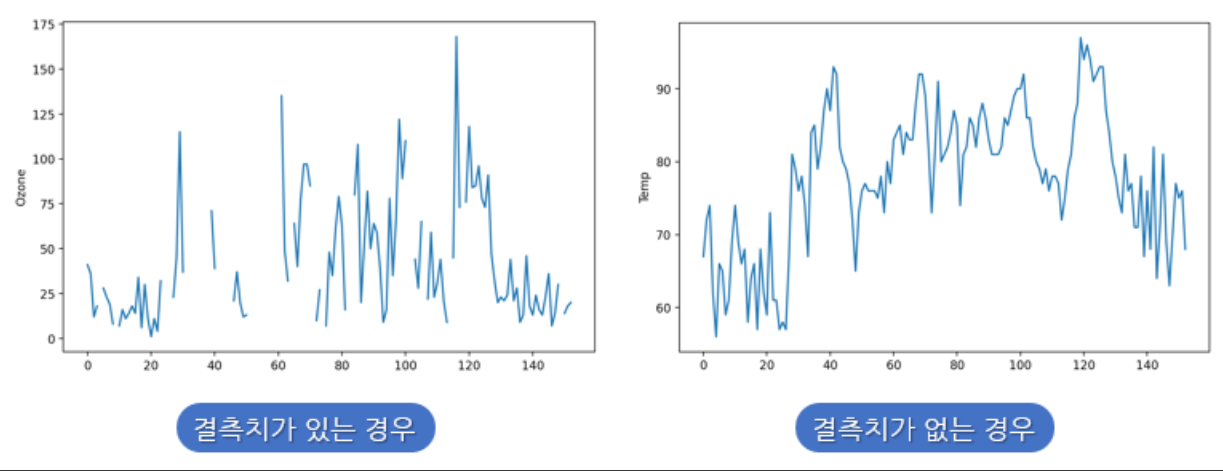

- NaN 값은 제거하든지 다른 값(예를 들면 평균값, 최빈값 등)으로 채워야 한다.

- 결측치는 어떻게 처리해야 될까? -> 비율에 따라 다르게
    - **결측치가 데이터의 5% 미만** : 일부분에만 결측치가 존재하므로 결측치가 있는 행을 삭제하는 것이 적절.이렇게 하면 데이터 손실이 최소화되며, 분석의 신뢰성에 큰 영향을 미치지 않음.
    - **결측치가 데이터의 5%에서 20% 사이** : 결측치가 꽤 많은 상태이므로 삭제보다는 대체하는 방법이 더 적합. 평균, 중간값, 최빈값 등을 사용해 대체하거나, 필요에 따라 모델 기반 처리도 고려.
    - **결측치가 데이터의 20% 이상** : 결측치가 너무 많은 상태이므로 결측치가 있는 열 전체를 제거하는 것이 권장되지만, 데이터 손실이 크기 때문에 신중한 판단이 필요. 특히 데이터셋이 작거나 해당 변수가 중요한 역할을 할 때는 모델 기반 대체나 예측 모델을 통해 결측치를 보완하는 것이 더 적합할 수 있음. 따라서, 결측치가 20% 이상이라도 변수의 중요성, 분석 목적, 데이터 양을 종합적으로 고려해 열을 제거할지, 대체할지를 결정하는 것이 중요.


- 다만, 이러한 기준은 이론적인 가이드라인일 뿐, 절대적인 규칙은 아니다. 데이터의 특성, 분석 목적, 실무 환경에 따라 다양한 조정이 필요할 수 있다.


**[airquality 데이터 셋 정보]**

- Ozone: 오존 농도  
- Solar.R: 태양복사량
- Wind: 풍속
- Temp: 기온
- Month: 월
- Day: 일

In [4]:
path = './../00_data/airquality.csv'
air = pd.read_csv(path)

air.head()

,Ozone,Solar.R,Wind,Temp,Month,Day
0,41.0,190.0,7.4,67,5,1
1,36.0,118.0,8.0,72,5,2
2,12.0,149.0,12.6,74,5,3
3,18.0,313.0,11.5,62,5,4
4,NaN,NaN,14.3,56,5,5


### 6.1.1.결측치 확인하기

- 결측치 존재 여부를 확인하고 이를 어떻게 처리할 지 방법을 결정해야 한다.

**1) info() 메소드로 확인**

In [8]:
air.info()

<class 'pandas.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Ozone    116 non-null    float64
 1   Solar.R  146 non-null    float64
 2   Wind     153 non-null    float64
 3   Temp     153 non-null    int64  
 4   Month    153 non-null    int64  
 5   Day      153 non-null    int64  
dtypes: float64(3), int64(3)
memory usage: 7.3 KB


**2) isnull(), notnull() 메소드 사용**

- **isnull()** 메소드는 결측치면 True, 유효한 값이면 False를 반환한다.
- **notnull()** 메소드는 결측치면 False, 유효한 값이면 True를 반환한다.
- isnull() 대신 **isna()**, notnull() 대신 **notna()** 메소드를 사용해도 된다.

In [5]:
# 전체 데이터 중에서 결측치는 True로 표시
air.isnull()

,Ozone,Solar.R,Wind,Temp,Month,Day
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,True,True,False,False,False,False
...,...,...,...,...,...,...
148,False,False,False,False,False,False
149,True,False,False,False,False,False
150,False,False,False,False,False,False
151,False,False,False,False,False,False


In [6]:
# 전체 데이터 중에서 결측치는 True로 표시
air.isnull().sum()

Ozone      37
Solar.R     7
Wind        0
Temp        0
Month       0
Day         0
dtype: int64

In [7]:
air.isna().sum()

Ozone      37
Solar.R     7
Wind        0
Temp        0
Month       0
Day         0
dtype: int64

In [9]:
# 전체 데이터 중에서 결측치는 False로 표시
air.notnull().sum()

Ozone      116
Solar.R    146
Wind       153
Temp       153
Month      153
Day        153
dtype: int64

In [10]:
# 전체 데이터 중에서 결측치는 False로 표시
air.notna().sum()

Ozone      116
Solar.R    146
Wind       153
Temp       153
Month      153
Day        153
dtype: int64

- **sum()** 메소드를 사용해 True 값의 개수, 즉 **열의 결측치 개수**를 확인할 수 있다.

In [12]:
# 열의 결측치 비율 확인
air.isna().sum() / len(air) * 100

Ozone      24.183007
Solar.R     4.575163
Wind        0.000000
Temp        0.000000
Month       0.000000
Day         0.000000
dtype: float64

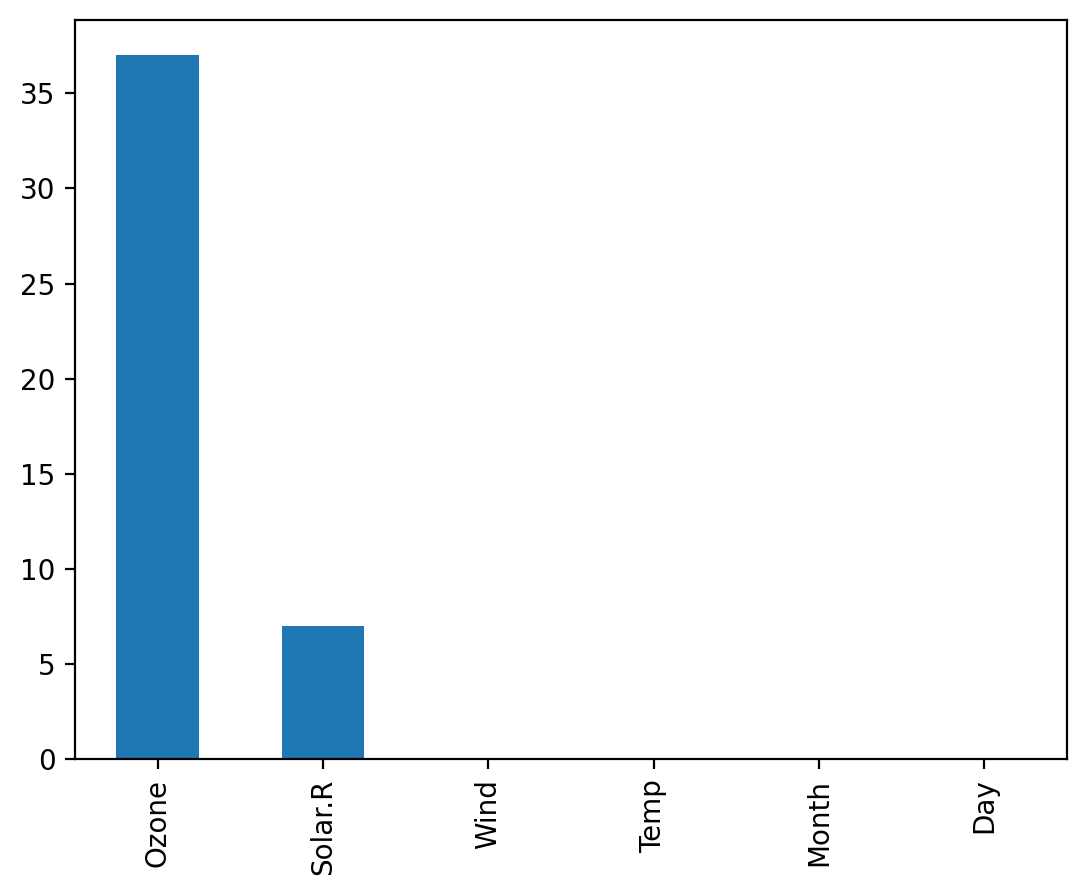

In [13]:
# 시각화
air.isna().sum().plot(kind='bar')
plt.show()

### 6.1.2.결측치 제거

- **dropna()** 메소드로 결측치가 있는 열이나 행을 제거할 수 있다.
- inplace=True 옵션을 지정해야 해당 데이터프레임에 실제로 반영된다.
- axis 옵션으로 행을 제거할지 열을 제거할지 지정한다.
    - axis=0: 행 제거(기본값)
    - axis=1: 열 제거

**1) 어떤 열이든 결측치가 있는 행 제거**

- dropna() 메소드는 기본적으로 어느 열이든 결측치가 있는 행을 제거한다.

In [14]:
# 데이터프레임 복사
air_test = air.copy()

# 열의 결축치 개수 확인
air_test.isna().sum()

Ozone      37
Solar.R     7
Wind        0
Temp        0
Month       0
Day         0
dtype: int64

In [17]:
air_test.info()

<class 'pandas.DataFrame'>
Index: 111 entries, 0 to 152
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Ozone    111 non-null    float64
 1   Solar.R  111 non-null    float64
 2   Wind     111 non-null    float64
 3   Temp     111 non-null    int64  
 4   Month    111 non-null    int64  
 5   Day      111 non-null    int64  
dtypes: float64(3), int64(3)
memory usage: 6.1 KB


In [16]:
# 결측치가 하나라도 있는 행 제거
air_test.dropna(axis=0, inplace=True)
air_test.isna().sum()

Ozone      0
Solar.R    0
Wind       0
Temp       0
Month      0
Day        0
dtype: int64

**2) 특정 열에 결측치가 있는 행 제거**

- subset 옵션에 열을 지정해 해당 열에 결측치가 있는 행을 제거한다..

In [20]:
air_test2 = air.copy()
air_test2.dropna(subset='Ozone', axis=0, inplace=True)

air_test2.isna().sum()

Ozone      0
Solar.R    5
Wind       0
Temp       0
Month      0
Day        0
dtype: int64

In [22]:
air_test2.head()

,Ozone,Solar.R,Wind,Temp,Month,Day
0,41.0,190.0,7.4,67,5,1
1,36.0,118.0,8.0,72,5,2
2,12.0,149.0,12.6,74,5,3
3,18.0,313.0,11.5,62,5,4
5,28.0,NaN,14.9,66,5,6


**3) 결측치가 있는 모든 열 제거**

- axis=1 옵션을 지정해 열을 제거할 수 있다.

In [ ]:
air_test3 = air.copy()
air_test3.dropna(axis=1, inplace=True)

air_test3.isna().sum()

Wind     0
Temp     0
Month    0
Day      0
dtype: int64

In [24]:
air_test3.head()

,Wind,Temp,Month,Day
0,7.4,67,5,1
1,8.0,72,5,2
2,12.6,74,5,3
3,11.5,62,5,4
4,14.3,56,5,5


### 6.1.3.결측치 채우기

- **fillna()** 메소드를 사용해 결측치를 다른 값으로 채울 수 있다.

**1) 평균값으로 채우기**

- 결측치가 있는 열의 평균값을 구한 후 결측치를 그 값으로 채운다.

In [26]:

air_test4 = air.copy()

# Ozone 평균 구하기
mean_ozone = air_test4['Ozone'].mean()

# 결측치 평균값으로 채우기
air_test4['Ozone'] = air_test4['Ozone'].fillna(mean_ozone)

air_test4.isna().sum()


Ozone      0
Solar.R    7
Wind       0
Temp       0
Month      0
Day        0
dtype: int64

**2) 특정 값으로 채우기**

- 모든 결측치, 또는 일부 결측치를 특정 값으로 채운다.

In [27]:
air_test4['Solar.R'] = air_test4['Solar.R'].fillna(0)

air_test4.isna().sum()

Ozone      0
Solar.R    0
Wind       0
Temp       0
Month      0
Day        0
dtype: int64

**4) 직전 행의 값 또는 바로 다음 행의 값으로 채우기**

- 결측치를 바로 앞의 값이나 바로 다음에 나오는 값으로 채운다.
- 날짜 또는 시간의 흐름에 따른 값을 갖는 시계열 데이터 처리시 유용하다.
- **DataFrame.ffill()**: 바로 앞의 값으로 변경(Fowared Fill)
- **DataFrame.bfill()**: 바로 다음 값으로 변경(Backwared Fill)

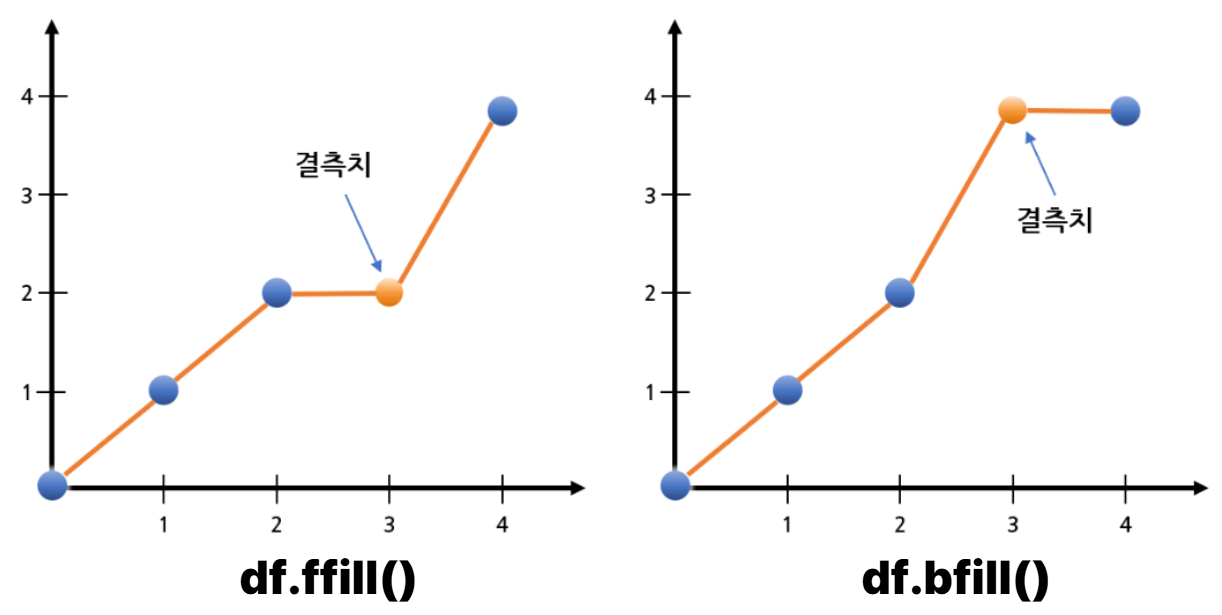

In [28]:
air_test5 = air.copy()

air_test5.isna().sum()

Ozone      37
Solar.R     7
Wind        0
Temp        0
Month       0
Day         0
dtype: int64

In [29]:
# Ozone 열의 누락된 값을 바로 앞의 값으로 채우기
air_test5['Ozone'] = air_test5['Ozone'].ffill()

# Solar.R 열의 누락된 값을 바로 뒤의 값으로 채우기
air_test5['Solar.R'] = air_test5['Solar.R'].bfill()
air_test5.isna().sum()

Ozone      0
Solar.R    0
Wind       0
Temp       0
Month      0
Day        0
dtype: int64

**5) 선형보간법으로 채우기**

- **interpolate()** 메소드를 사용해 선형보간법으로 채울 수 있다.

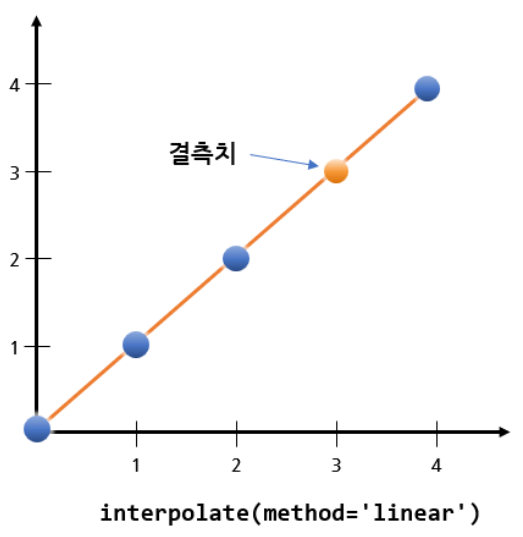

In [31]:
air_test6 = air.copy()

# 선형보간법으로 채우기
air_test6['Ozone'] = air_test6['Ozone'].interpolate(method='linear')
air_test6['Solar.R'] = air_test6['Solar.R'].interpolate(method='linear')

air_test6.isna().sum()


Ozone      0
Solar.R    0
Wind       0
Temp       0
Month      0
Day        0
dtype: int64

## 6.2.가변수(Dummy Variable) 만들기

- 가변수는 일정하게 정해진 범위의 값을 갖는 데이터(범주형 데이터)를 독립된 열로 변환한 것이다.
- 특히 범주형 문자열 데이터는 머신러닝 알고리즘에 사용하려면 숫자로 변환해야 한다.
- 가변수를 만드는 과정을 **One-Hot-Encoding** 이라고 부르기도 한다.
- **get_dummies()** 함수를 사용해서 가변수를 쉽게 만들 수 있다.

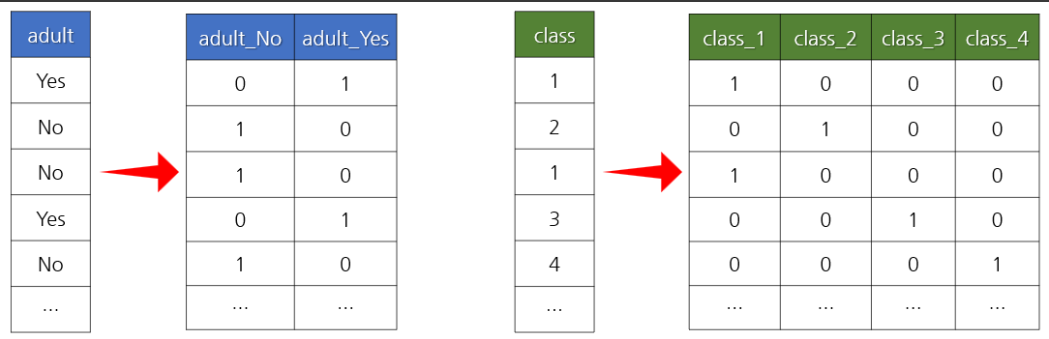

In [34]:
path = './../00_data/tips.csv'
tips = pd.read_csv(path)
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


### 6.2.1.범주형 변수 확인

- 범주형 여부를 우선 확인해야 한다.
- 문자열 값을 갖는 열이 범수형 값을 갖는 경우가 많다.

In [33]:
tips.info()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    str    
 3   smoker      244 non-null    str    
 4   day         244 non-null    str    
 5   time        244 non-null    str    
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), str(4)
memory usage: 13.5 KB


### 6.2.2.변수 개별 처리

- columns 옵션에 열을 하나 지정해 처리할 수 있다.
- 자동으로 원본 열이 제거되고, 열 이름이 prefix로 사용된다.
- 다중공선성 문제를 없애기 위해 **drop_first=True** 옵션을 지정한다.

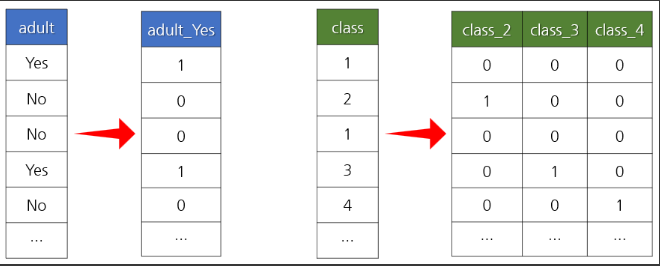

**[참고] 다중공선성 문제**
- 통계학의 회귀분석에서 독립변수들 간에 강한 상관관계가 나타나는 문제이다.
- 독립변수들 간에 정확한 선형관계가 존재하는 **완전공선성**의 경우와 독립변수들 간에 높은 선형관계가 존재하는 **다중공선성**으로 구분하기도 한다.
- 이는 회귀분석의 전제 가정을 위배하는 것이므로 적절한 회구분석을 위해 해결해야 하는 문제가 된다.(위키백과)

In [36]:
tips2 = tips.copy()
cols = ['sex']

tips2 = pd.get_dummies(tips2, columns=cols)

tips2.head()

,total_bill,tip,smoker,day,time,size,sex_Female,sex_Male
0,16.99,1.01,No,Sun,Dinner,2,True,False
1,10.34,1.66,No,Sun,Dinner,3,False,True
2,21.01,3.50,No,Sun,Dinner,3,False,True
3,23.68,3.31,No,Sun,Dinner,2,False,True
4,24.59,3.61,No,Sun,Dinner,4,True,False


In [ ]:
# 가변수화로 만들어지는 열 순서

# 기본원칙 : 알파벳 순서 (대문자 -> 소문자 -> 숫자 -> 특수문자)
tips2 = tips.copy()
cols = ['sex']

tips2 = pd.get_dummies(tips2, columns=cols, drop_first=True)

tips2.head()

,total_bill,tip,smoker,day,time,size,sex_Male
0,16.99,1.01,No,Sun,Dinner,2,False
1,10.34,1.66,No,Sun,Dinner,3,True
2,21.01,3.50,No,Sun,Dinner,3,True
3,23.68,3.31,No,Sun,Dinner,2,True
4,24.59,3.61,No,Sun,Dinner,4,False


### 6.2.3.일괄 처리

- columns 옵션에 대상 열을 **리스트**로 지정해 한 번에 처리한다.
- 자동으로 열 이름이 prefix로 지정되며 원본 열이 제거된다.
- columns 옵션을 지정하지 않으면 문자열 값을 갖는 열 모두를 대상으로 한다.

In [38]:
# 여러 번주형 변수를 가변수화 : smoker, day, time

tips3 = tips.copy()

cols = ['smoker', 'day', 'time']

tips3 = pd.get_dummies(tips3, columns=cols, drop_first=True)
tips3.head()

,total_bill,tip,sex,size,smoker_Yes,day_Sat,day_Sun,day_Thur,time_Lunch
0,16.99,1.01,Female,2,False,False,True,False,False
1,10.34,1.66,Male,3,False,False,True,False,False
2,21.01,3.50,Male,3,False,False,True,False,False
3,23.68,3.31,Male,2,False,False,True,False,False
4,24.59,3.61,Female,4,False,False,True,False,False
